# Washington COVID-19 Case Forecasting Using LSTM

This notebook implements an LSTM-based time-series forecasting approach for cumulative COVID-19 confirmed cases in Washington State.

The model is trained on historical case information and evaluated on the final **90 days** of the available dataset. I first convert the cumulative case series into daily changes, because the daily change series is more suitable for learning temporal patterns than the continuously increasing cumulative total. The LSTM predicts the next 90 daily changes, and these predictions are then converted back into cumulative case counts for comparison with the actual test data.

The paper describes its RNN forecasting method as an **LSTM**. Therefore, the architecture and hyperparameters used here are clearly defined implementation choices for reproducing the LSTM forecasting approach.


## 1. Libraries and reproducibility

I import the libraries required for data handling, visualization, preprocessing, model training, and evaluation.

Random seeds are also fixed so that the LSTM initialization and training are more reproducible across repeated runs.


In [1]:

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 2. Load the Washington dataset

I load the Washington state-level cumulative confirmed-case dataset produced during the data preparation stage.

The dataset contains one observation per date with two main columns: `Date` and `ConfirmedCases`.


In [2]:

path = "./washington_covid_confirmed.csv"

data = pd.read_csv(path)

print("Shape:", data.shape)
print("Columns:", data.columns.tolist())

data.head()


Shape: (1104, 2)
Columns: ['Date', 'ConfirmedCases']


,Date,ConfirmedCases
0,2020-03-01,11
1,2020-03-02,18
2,2020-03-03,27
3,2020-03-04,39
4,2020-03-05,70


## 3. Prepare the cumulative time series

I convert the date column to datetime format, make sure the confirmed-case values are numeric, remove invalid observations, and sort the data chronologically.

Time order must be preserved because the forecasting model learns from earlier observations to predict later observations.


In [3]:

required_columns = {"Date", "ConfirmedCases"}

missing = required_columns - set(data.columns)

if missing:
    raise ValueError(f"Missing required columns: {missing}")

data = data[["Date", "ConfirmedCases"]].copy()

data["Date"] = pd.to_datetime(data["Date"])
data["ConfirmedCases"] = pd.to_numeric(
    data["ConfirmedCases"],
    errors="coerce"
)

data = (
    data
    .dropna(subset=["Date", "ConfirmedCases"])
    .sort_values("Date")
    .drop_duplicates(subset=["Date"])
    .reset_index(drop=True)
)

print("Final shape:", data.shape)
print("Start date:", data["Date"].min())
print("End date:", data["Date"].max())

data.head()


Final shape: (1104, 2)
Start date: 2020-03-01 00:00:00
End date: 2023-03-09 00:00:00


,Date,ConfirmedCases
0,2020-03-01,11
1,2020-03-02,18
2,2020-03-03,27
3,2020-03-04,39
4,2020-03-05,70


## 4. Convert cumulative cases to daily changes

The original target is cumulative confirmed cases, which continuously increase over time. Instead of training the LSTM directly on these large cumulative totals, I calculate the change from one day to the next:

`DailyCases[t] = ConfirmedCases[t] - ConfirmedCases[t-1]`

This gives the model a series that represents how much the cumulative count changed each day. After forecasting these changes, I reconstruct the cumulative case forecast by adding the predicted changes back to the last known cumulative value.


In [4]:

data["DailyCases"] = data["ConfirmedCases"].diff()

data = data.dropna().reset_index(drop=True)

print("Minimum daily change:", data["DailyCases"].min())
print("Maximum daily change:", data["DailyCases"].max())
print("Negative-change days:", int((data["DailyCases"] < 0).sum()))

data.head(10)


Minimum daily change: -2220.0
Maximum daily change: 64166.0
Negative-change days: 10


,Date,ConfirmedCases,DailyCases
0,2020-03-02,18,7.0
1,2020-03-03,27,9.0
2,2020-03-04,39,12.0
3,2020-03-05,70,31.0
4,2020-03-06,78,8.0
5,2020-03-07,102,24.0
6,2020-03-08,122,20.0
7,2020-03-09,122,0.0
8,2020-03-10,167,45.0
9,2020-03-11,282,115.0


## 5. Create chronological training, validation, and test periods

The data are divided in chronological order:

- **Training set:** historical observations used to learn the LSTM parameters.
- **Validation set:** 180 days used to monitor model performance during training.
- **Test set:** the final 90 days used only for the final forecasting evaluation.

The test period is kept separate from model training so the final RMSE measures performance on future observations that the model did not learn from.


In [5]:

LOOKBACK = 60
HORIZON = 90
VALIDATION_DAYS = 180

n = len(data)

test_start = n - HORIZON
val_start = test_start - VALIDATION_DAYS
train_end = val_start

if train_end <= LOOKBACK + HORIZON:
    raise ValueError(
        "Not enough observations for the requested train/validation/test design."
    )

train_block = data.iloc[:train_end].copy()
validation_block = data.iloc[val_start:test_start].copy()
test_block = data.iloc[test_start:].copy()

print("Training observations  :", len(train_block))
print("Validation observations:", len(validation_block))
print("Test observations      :", len(test_block))

print("\nTraining period:")
print(train_block["Date"].min(), "to", train_block["Date"].max())

print("\nValidation period:")
print(validation_block["Date"].min(), "to", validation_block["Date"].max())

print("\nTest period:")
print(test_block["Date"].min(), "to", test_block["Date"].max())


Training observations  : 833
Validation observations: 180
Test observations      : 90

Training period:
2020-03-02 00:00:00 to 2022-06-12 00:00:00

Validation period:
2022-06-13 00:00:00 to 2022-12-09 00:00:00

Test period:
2022-12-10 00:00:00 to 2023-03-09 00:00:00


## 6. Visualize the data split

This graph shows the training, validation, and test periods on the original cumulative case curve.

Visualizing the split makes it clear which historical period is used for learning and which final 90-day period is reserved for evaluating the forecast.


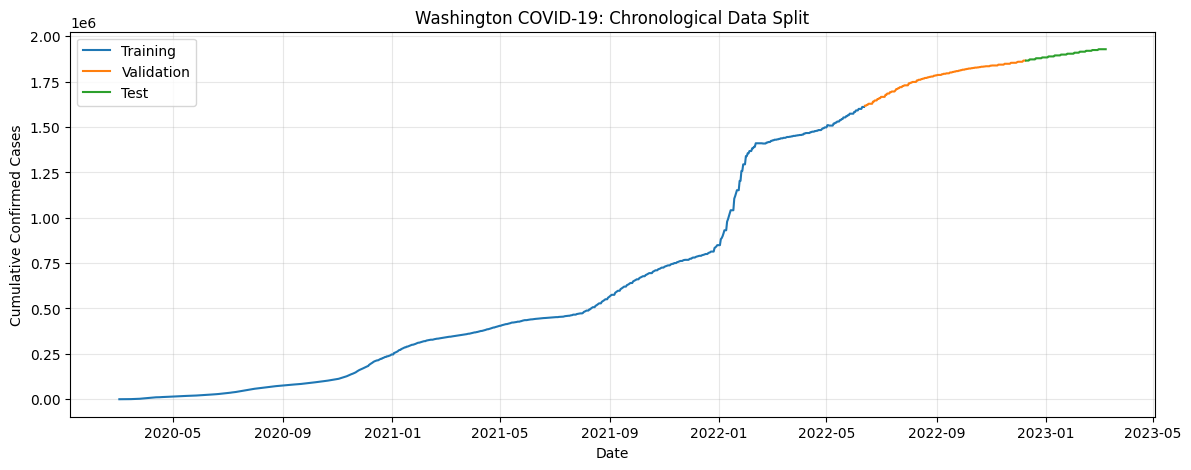

In [6]:

plt.figure(figsize=(14, 5))

plt.plot(
    train_block["Date"],
    train_block["ConfirmedCases"],
    label="Training"
)

plt.plot(
    validation_block["Date"],
    validation_block["ConfirmedCases"],
    label="Validation"
)

plt.plot(
    test_block["Date"],
    test_block["ConfirmedCases"],
    label="Test"
)

plt.title("Washington COVID-19: Chronological Data Split")
plt.xlabel("Date")
plt.ylabel("Cumulative Confirmed Cases")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 7. Standardize the daily-change values

LSTM training is more stable when input values are on a comparable numerical scale.

I fit a `StandardScaler` using only the training-period daily changes. The same scaler is then used to transform the remaining observations. This keeps the preprocessing parameters based on historical training information rather than future data.


In [7]:

scaler = StandardScaler()

scaler.fit(
    train_block[["DailyCases"]]
)

all_daily_scaled = scaler.transform(
    data[["DailyCases"]]
)

print("Scaler mean learned from training only:", scaler.mean_[0])
print("Scaler standard deviation:", scaler.scale_[0])


Scaler mean learned from training only: 1933.7118847539016
Scaler standard deviation: 5041.594167654051


## 8. Create LSTM training sequences

The daily-change series is converted into supervised input-output sequences.

For each training example:

- the previous **60 days** are used as the input sequence;
- the following **90 days** are used as the target sequence.

The resulting input shape is `(samples, 60, 1)`, where 60 represents the time steps and 1 represents the single feature, daily case change. The output contains 90 values because the model is trained to forecast the complete 90-day horizon directly.


In [8]:

def create_training_sequences(
    scaled_values,
    train_end_index,
    lookback,
    horizon
):
    X = []
    y = []

    for target_start in range(
        lookback,
        train_end_index - horizon + 1
    ):
        input_start = target_start - lookback
        target_end = target_start + horizon

        X.append(
            scaled_values[input_start:target_start, 0]
        )

        y.append(
            scaled_values[target_start:target_end, 0]
        )

    X = np.asarray(X)
    y = np.asarray(y)

    X = X.reshape(
        X.shape[0],
        lookback,
        1
    )

    return X, y


X_train, y_train = create_training_sequences(
    all_daily_scaled,
    train_end,
    LOOKBACK,
    HORIZON
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (684, 60, 1)
y_train shape: (684, 90)


## 9. Prepare validation forecast windows

The validation period is divided into two separate 90-day forecasting windows.

For each validation window, the LSTM receives the 60 observations immediately before the forecast start and predicts the following 90 days. This allows validation to reflect the same type of multi-step forecasting task used for the final test period.


In [9]:

validation_target_starts = [
    val_start,
    val_start + HORIZON
]

X_val = []
y_val = []

for target_start in validation_target_starts:
    input_start = target_start - LOOKBACK
    target_end = target_start + HORIZON

    if input_start < 0:
        raise ValueError("Not enough history for validation lookback.")

    if target_end > test_start:
        raise ValueError("Validation target overlaps the test period.")

    X_val.append(
        all_daily_scaled[
            input_start:target_start,
            0
        ]
    )

    y_val.append(
        all_daily_scaled[
            target_start:target_end,
            0
        ]
    )

X_val = np.asarray(X_val).reshape(
    len(validation_target_starts),
    LOOKBACK,
    1
)

y_val = np.asarray(y_val)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

for i, target_start in enumerate(validation_target_starts, start=1):
    target_end = target_start + HORIZON - 1

    print(
        f"Validation target {i}:",
        data.iloc[target_start]["Date"].date(),
        "to",
        data.iloc[target_end]["Date"].date()
    )


X_val shape: (2, 60, 1)
y_val shape: (2, 90)
Validation target 1: 2022-06-13 to 2022-09-10
Validation target 2: 2022-09-11 to 2022-12-09


## 10. Check the time boundaries

Before training, I verify the dates at the boundaries of the training, validation, and test target periods.

This confirms that the forecasting targets are ordered chronologically and that the final test period begins only after the validation period is complete.


In [10]:

last_training_target_end = train_end - 1
first_validation_target_start = validation_target_starts[0]

last_validation_target_end = validation_target_starts[-1] + HORIZON - 1
first_test_target_start = test_start

print(
    "Last training target date:",
    data.iloc[last_training_target_end]["Date"].date()
)

print(
    "First validation target date:",
    data.iloc[first_validation_target_start]["Date"].date()
)

print(
    "Last validation target date:",
    data.iloc[last_validation_target_end]["Date"].date()
)

print(
    "First test date:",
    data.iloc[first_test_target_start]["Date"].date()
)

assert last_training_target_end < first_validation_target_start
assert last_validation_target_end < first_test_target_start

print("\nNo target overlap between training, validation, and test periods.")


Last training target date: 2022-06-12
First validation target date: 2022-06-13
Last validation target date: 2022-12-09
First test date: 2022-12-10

No target overlap between training, validation, and test periods.


## 11. Define the LSTM architecture

The network contains two LSTM layers followed by dense layers:

1. **LSTM with 64 units** to learn temporal patterns from the input sequence.
2. **Dropout (20%)** to reduce overfitting.
3. **LSTM with 32 units** to further summarize the learned sequence information.
4. **Dropout (20%)** for additional regularization.
5. **Dense layer with 64 ReLU units** to transform the learned representation.
6. **Dense output layer with 90 units** to predict the next 90 daily changes.

The first LSTM returns the full sequence so that the second LSTM can process temporal information from all 60 input steps.


In [11]:

model = Sequential([
    Input(shape=(LOOKBACK, 1)),

    LSTM(
        64,
        return_sequences=True
    ),

    Dropout(0.20),

    LSTM(32),

    Dropout(0.20),

    Dense(
        64,
        activation="relu"
    ),

    Dense(HORIZON)
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 90)                  │           5,850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,274 (145.60 KB)

 Trainable params: 37,274 (145.60 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Configure the training process

I use the **Adam optimizer** with a learning rate of `0.001`.

The model is trained with **Huber loss**. Huber loss is useful for this dataset because daily COVID reporting can contain occasional large spikes or corrections. It behaves similarly to squared error for small errors while reducing the influence of very large outliers.


In [12]:

model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss=Huber()
)


## 13. Train the LSTM

The model is trained using the prepared training sequences and evaluated on the validation forecast windows after each epoch.

Two callbacks are used:

- **EarlyStopping** stops training when validation performance no longer improves and restores the best model weights.
- **ReduceLROnPlateau** lowers the learning rate when validation loss stops improving.

`shuffle=False` is used because the observations represent ordered time-series sequences.


In [13]:

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_val,
        y_val
    ),
    epochs=250,
    batch_size=32,
    shuffle=False,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)


Epoch 1/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - loss: 0.1956 - val_loss: 0.1135 - learning_rate: 0.0010
Epoch 2/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.1932 - val_loss: 0.1117 - learning_rate: 0.0010
Epoch 3/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.1918 - val_loss: 0.1106 - learning_rate: 0.0010
Epoch 4/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.1909 - val_loss: 0.1101 - learning_rate: 0.0010
Epoch 5/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.1906 - val_loss: 0.1100 - learning_rate: 0.0010
Epoch 6/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.1903 - val_loss: 0.1097 - learning_rate: 0.0010
Epoch 7/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.1899 - val_loss: 0.1097 - learning_rate: 0.0010
Epoch 8/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.1895 - val_loss: 0.1097 - learning_rate: 0.0010
Epoch 9/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.1894 - val_loss: 0.1097 - learning_rate: 0.0010
Epoch 10/2

## 14. Examine training and validation loss

I plot the training and validation loss across epochs.

This helps assess whether the model is learning useful patterns and whether its performance on the validation forecasts remains stable. A large separation between training and validation loss can indicate overfitting.


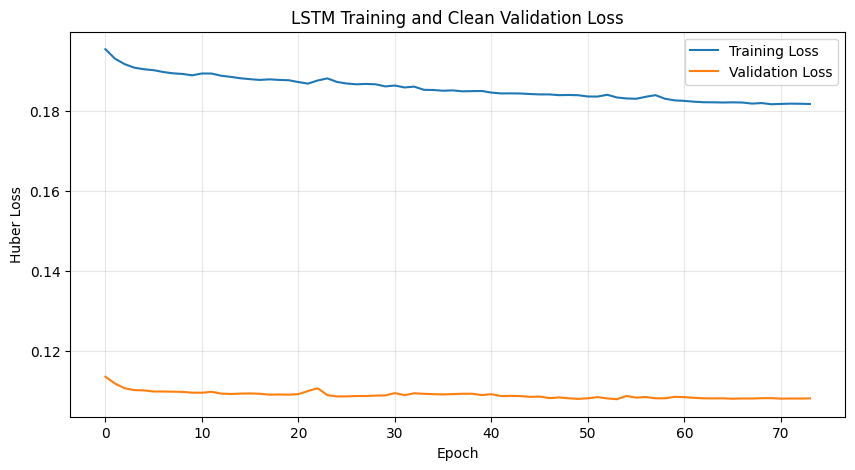

In [14]:

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Clean Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 15. Forecast the final 90-day test period

For the final forecast, I take the last **60 actual daily changes before the test period** and provide them to the trained LSTM.

The network produces all **90 future daily-change predictions in a single forward pass**. The test observations themselves are not used as inputs when generating this forecast.


In [15]:

test_input_start = test_start - LOOKBACK

X_test = all_daily_scaled[
    test_input_start:test_start,
    0
].reshape(
    1,
    LOOKBACK,
    1
)

forecast_scaled = model.predict(
    X_test,
    verbose=0
)[0]

print("Forecast horizon:", forecast_scaled.shape)


Forecast horizon: (90,)


## 16. Convert predictions back to daily case-change units

The LSTM outputs standardized values, so I apply the inverse transformation of the training scaler.

The resulting values represent predicted daily changes in the original case-count scale. I also inspect their minimum, maximum, and mean to understand the magnitude of the predicted changes.


In [16]:

forecast_daily = scaler.inverse_transform(
    forecast_scaled.reshape(-1, 1)
).flatten()

print("Minimum predicted daily change:", forecast_daily.min())
print("Maximum predicted daily change:", forecast_daily.max())
print("Mean predicted daily change:", forecast_daily.mean())

print("\nFirst 10 predicted daily changes:")
print(forecast_daily[:10])


Minimum predicted daily change: 996.2628
Maximum predicted daily change: 1996.3894
Mean predicted daily change: 1616.3003

First 10 predicted daily changes:
[ 996.2628 1207.4158 1389.1804 1375.7142 1382.48   1600.3538 1687.8356
 1534.094  1659.1727 1666.91  ]


## 17. Reconstruct cumulative confirmed cases

The final evaluation is performed on cumulative confirmed cases, so I convert the predicted daily changes back into a cumulative trajectory.

I start from the last known cumulative case count immediately before the test period and add the cumulative sum of the predicted daily changes:

`Forecast cumulative cases = Last known cumulative cases + cumulative sum(predicted daily changes)`

This produces one cumulative prediction for each of the 90 test days.


In [17]:

last_known_cumulative = data.iloc[
    test_start - 1
]["ConfirmedCases"]

forecast_cumulative = (
    last_known_cumulative
    + np.cumsum(forecast_daily)
)

actual_cumulative = test_block[
    "ConfirmedCases"
].to_numpy()

print("Last known cumulative value:", last_known_cumulative)
print("First predicted cumulative:", forecast_cumulative[0])
print("Last predicted cumulative:", forecast_cumulative[-1])


Last known cumulative value: 1866343
First predicted cumulative: 1867339.2628173828
Last predicted cumulative: 2011810.03125


## 18. Evaluate the forecast using MSE and RMSE

I compare the 90 predicted cumulative case counts with the 90 actual cumulative values in the test period.

Two error metrics are calculated:

- **MSE (Mean Squared Error):** average of the squared differences between actual and predicted values.
- **RMSE (Root Mean Squared Error):** square root of MSE.

RMSE is especially useful here because it is expressed in the same unit as the cumulative case counts. **A lower RMSE indicates a more accurate forecast.**


In [18]:

test_mse = mean_squared_error(
    actual_cumulative,
    forecast_cumulative
)

test_rmse = np.sqrt(test_mse)

print("LSTM Test MSE :", test_mse)
print("LSTM Test RMSE:", test_rmse)


LSTM Test MSE : 2343462210.2377715
LSTM Test RMSE: 48409.3194564618


## 19. Plot the 90-day test forecast

This graph focuses only on the final 90-day test period.

The actual and predicted cumulative trajectories are shown together so I can visually examine whether the LSTM captures the direction and rate of change of the observed cases over the forecast horizon.


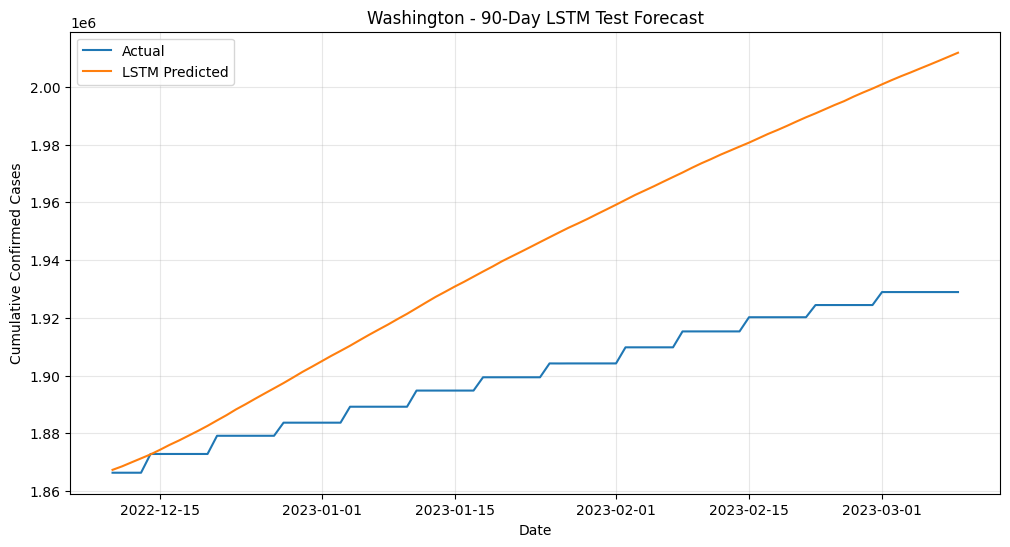

In [19]:

plt.figure(figsize=(12, 6))

plt.plot(
    test_block["Date"],
    actual_cumulative,
    label="Actual"
)

plt.plot(
    test_block["Date"],
    forecast_cumulative,
    label="LSTM Predicted"
)

plt.title("Washington - 90-Day LSTM Test Forecast")
plt.xlabel("Date")
plt.ylabel("Cumulative Confirmed Cases")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 20. View the forecast in the context of the full time series

This plot shows the complete experiment: training data, validation data, actual test data, and the LSTM forecast.

The full-history view provides context for where the 90-day forecasting period occurs within the overall Washington COVID-19 time series.


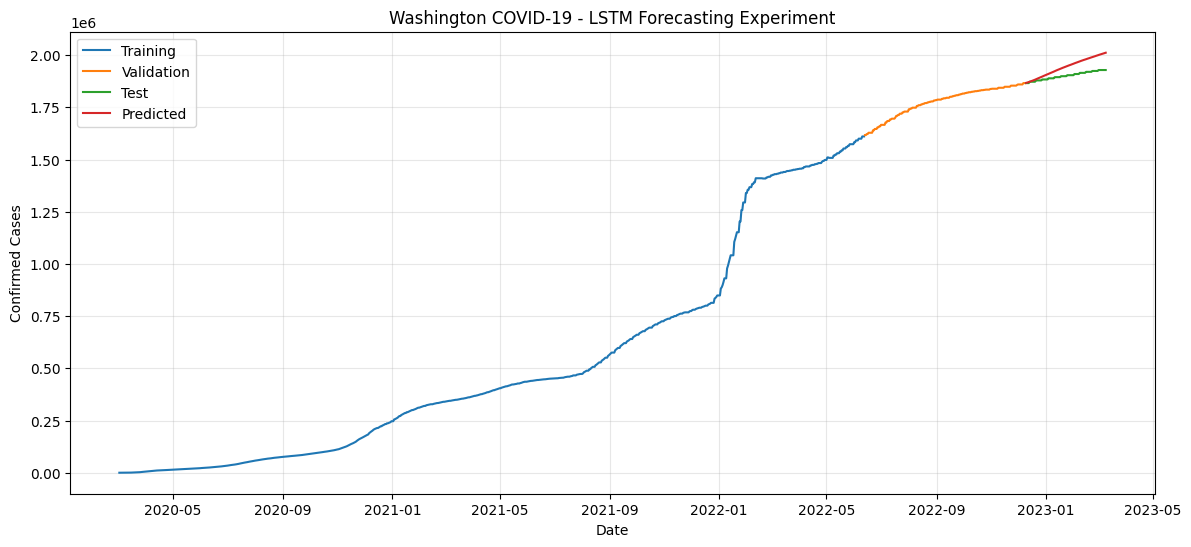

In [20]:

plt.figure(figsize=(14, 6))

plt.plot(
    train_block["Date"],
    train_block["ConfirmedCases"],
    label="Training"
)

plt.plot(
    validation_block["Date"],
    validation_block["ConfirmedCases"],
    label="Validation"
)

plt.plot(
    test_block["Date"],
    test_block["ConfirmedCases"],
    label="Test"
)

plt.plot(
    test_block["Date"],
    forecast_cumulative,
    label="Predicted"
)

plt.title("Washington COVID-19 - LSTM Forecasting Experiment")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 21. Save the test predictions

I save the test dates, actual cumulative values, LSTM predictions, and prediction errors to a CSV file.

This makes the final forecasting results available for later comparison with other forecasting models without retraining the LSTM.


In [21]:

results = pd.DataFrame({
    "Date": test_block["Date"].to_numpy(),
    "Actual": actual_cumulative,
    "LSTM_Predicted": forecast_cumulative
})

results["Error"] = (
    results["Actual"]
    - results["LSTM_Predicted"]
)

output_path = "./washington_lstm_corrected_predictions.csv"

results.to_csv(
    output_path,
    index=False
)

print("Saved predictions to:", output_path)

results.head(10)


Saved predictions to: ./washington_lstm_corrected_predictions.csv


,Date,Actual,LSTM_Predicted,Error
0,2022-12-10,1866343,1.867339e+06,-996.262817
1,2022-12-11,1866343,1.868547e+06,-2203.678711
2,2022-12-12,1866343,1.869936e+06,-3592.859131
3,2022-12-13,1866343,1.871312e+06,-4968.573242
4,2022-12-14,1872837,1.872694e+06,142.946777
5,2022-12-15,1872837,1.874294e+06,-1457.407227
6,2022-12-16,1872837,1.875982e+06,-3145.243164
7,2022-12-17,1872837,1.877516e+06,-4679.336914
8,2022-12-18,1872837,1.879176e+06,-6338.509766
9,2022-12-19,1872837,1.880842e+06,-8005.419922
